In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("youtube_cleaned.csv")

df.head()

,post_id,upload_date,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,YT0000001,2025-04-08 08:32:24.541512,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,YT0000002,2025-06-30 08:32:24.541512,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,YT0000003,2025-06-26 08:32:24.541512,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,YT0000004,2025-03-04 08:32:24.541512,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,YT0000005,2025-10-25 08:32:24.541512,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [33]:
df['upload_date'] = pd.to_datetime(df['upload_date'])

In [14]:
# ==========================================
# Sally's Section: Feature Engineering & Advanced Analysis
# ==========================================

df['engagement_rate'] = (
    df['likes'] + df['comments'] + df['shares']
) / df['impressions']

df['subscriber_conversion_rate'] = (
    df['subscribers_gained'] / df['impressions']
)

df['watch_time_per_impression'] = (
    df['total_watch_time_hours'] / df['impressions']
)

df['like_comment_ratio'] = (
    df['likes'] / (df['comments'] + 1)
)

df[
    [
        'engagement_rate',
        'subscriber_conversion_rate',
        'watch_time_per_impression',
        'like_comment_ratio'
    ]
].head()

,engagement_rate,subscriber_conversion_rate,watch_time_per_impression,like_comment_ratio
0,0.045197,0.000285,0.672778,83.509470
1,0.048875,0.000337,0.156111,11.876954
2,0.486676,0.006910,0.658056,10.123032
3,0.041365,0.000239,0.582500,24.657995
4,0.037221,0.000083,0.395556,18.103142


### Feature Engineering Insight

Additional metrics were created to better understand audience behavior and content effectiveness. The like-comment ratio helps evaluate the balance between passive engagement (likes) and active engagement (comments).

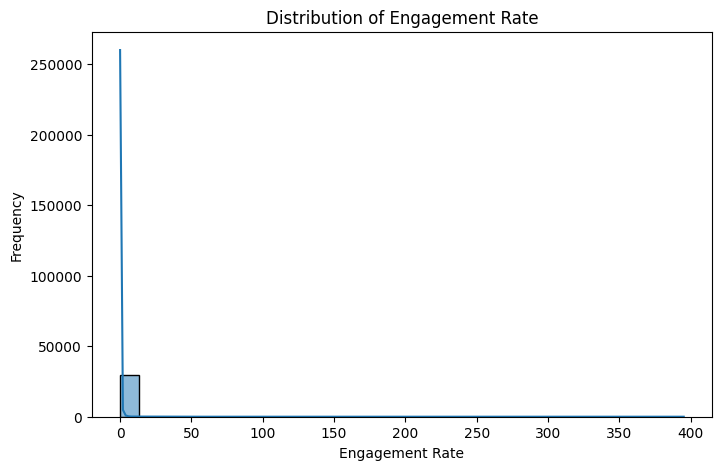

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['engagement_rate'], bins=30, kde=True)

plt.title('Distribution of Engagement Rate')
plt.xlabel('Engagement Rate')
plt.ylabel('Frequency')

plt.show()

### Insight

The distribution of engagement rates is highly right-skewed. Most videos generate relatively low engagement rates, while a small number of videos achieve exceptionally high engagement levels. This suggests that audience interaction is concentrated in a limited set of high-performing videos, which may significantly influence overall channel performance.

The maximum engagement rate observed in the dataset is substantially higher than the average value, indicating the presence of extreme outliers that contribute to the skewness of the distribution.

In [16]:
df['engagement_rate'].describe()

,engagement_rate
count,29999.000000
mean,0.287656
std,4.486942
min,0.000677
25%,0.030127
50%,0.055261
75%,0.109521
max,395.132075


In [17]:
df['engagement_rate'].nlargest(10)

,engagement_rate
9796,395.132075
7842,331.763158
14260,282.852941
6873,277.635965
2987,270.231834
12706,147.238636
3232,68.375758
22343,64.349220
20861,63.177562
12398,60.958993


In [18]:
df.nlargest(
    10,
    'engagement_rate'
)[
    [
        'post_id',
        'engagement_rate',
        'likes',
        'comments',
        'shares',
        'impressions'
    ]
]

,post_id,engagement_rate,likes,comments,shares,impressions
9796,YT0009797,395.132075,36679,2628,2577,106
7842,YT0007843,331.763158,82623,3991,1635,266
14260,YT0014261,282.852941,74650,2041,245,272
6873,YT0006874,277.635965,57604,4567,1130,228
2987,YT0002988,270.231834,70992,4549,2556,289
12706,YT0012707,147.238636,70645,6822,275,528
3232,YT0003233,68.375758,37595,6404,1129,660
22343,YT0022344,64.349220,72220,1378,661,1154
20861,YT0020862,63.177562,67507,2870,1140,1132
12398,YT0012399,60.958993,78939,2931,2863,1390


### Additional Observation

The highest engagement rates were associated with videos that generated very high levels of interaction despite having relatively low impression counts. These extreme observations contribute to the strong right-skewness observed in the distribution.

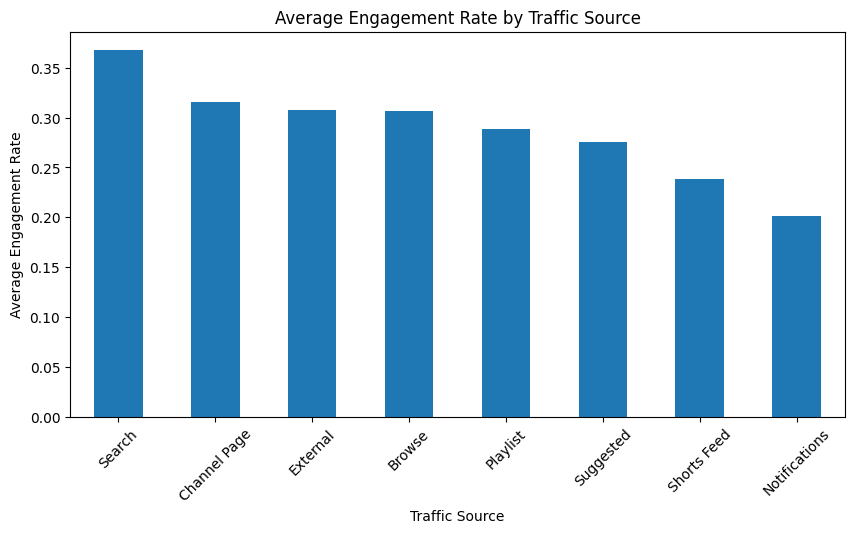

In [19]:
# ==========================================
# Traffic Source Analysis
# ==========================================

traffic_engagement = (
    df.groupby('traffic_source')['engagement_rate']
      .mean()
      .sort_values(ascending=False)
)

traffic_engagement.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Average Engagement Rate by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Average Engagement Rate')

plt.xticks(rotation=45)

plt.show()

### Insight

The analysis shows that engagement levels vary across traffic sources. Some traffic channels generate higher engagement rates than others, indicating that the quality of incoming viewers may be more important than the total number of impressions.

Traffic sources with stronger engagement should be prioritized because they are more likely to contribute to audience interaction and subscriber growth.

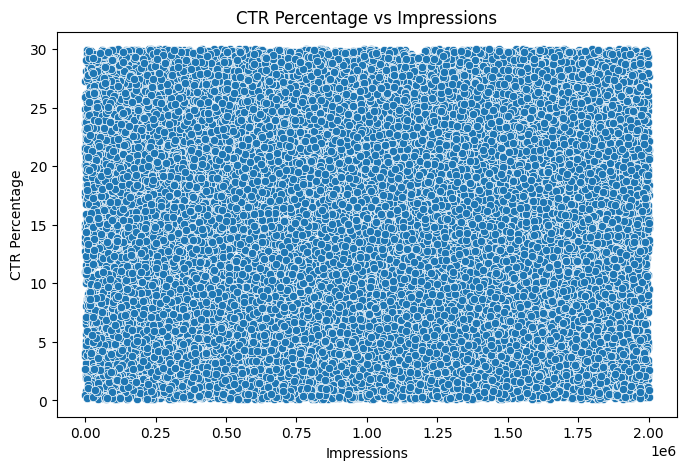

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='impressions',
    y='ctr_percentage'
)

plt.title('CTR Percentage vs Impressions')
plt.xlabel('Impressions')
plt.ylabel('CTR Percentage')

plt.show()

### Insight

The scatter plot shows no strong linear relationship between impressions and CTR percentage. Videos with both low and high impression counts appear across nearly the entire CTR range.

This suggests that generating more impressions does not necessarily lead to higher click-through rates. Factors such as thumbnail quality, video titles, content relevance, and audience targeting may have a greater influence on CTR performance than impressions alone.

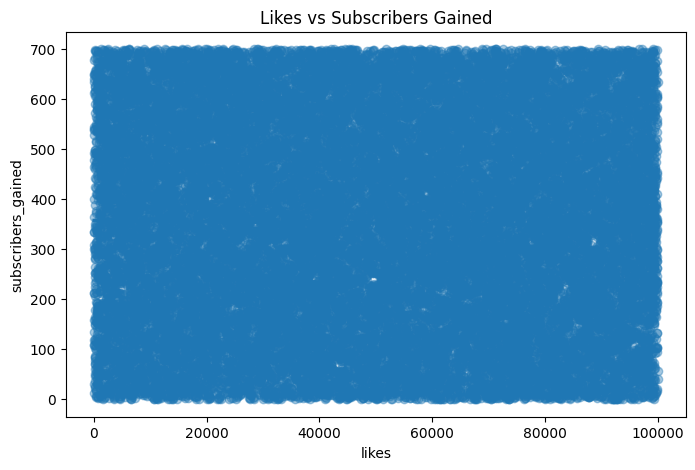

In [21]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='likes',
    y='subscribers_gained',
    scatter_kws={'alpha':0.4}
)

plt.title('Likes vs Subscribers Gained')

plt.show()

### Insight

The regression plot helps visualize the relationship between likes and subscriber growth. A positive trend suggests that videos receiving more audience interaction may contribute to increased subscriber acquisition.

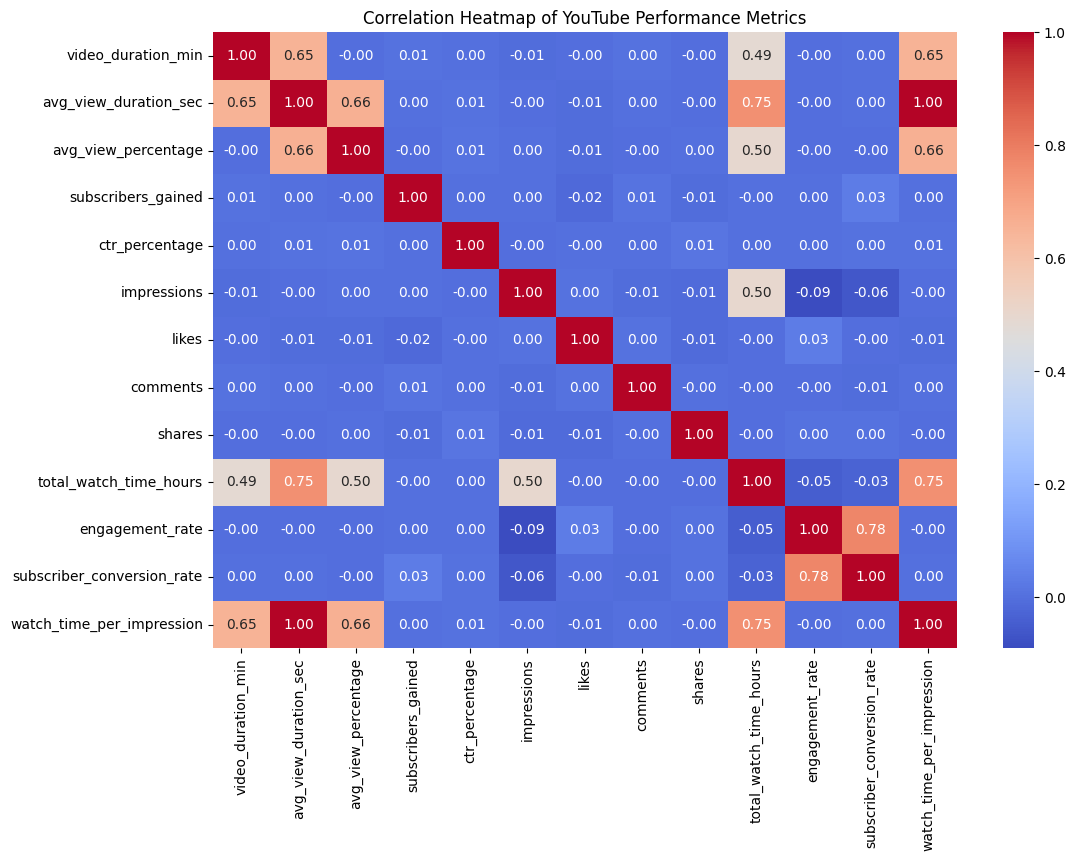

In [22]:
selected_columns = [
    'video_duration_min',
    'avg_view_duration_sec',
    'avg_view_percentage',
    'subscribers_gained',
    'ctr_percentage',
    'impressions',
    'likes',
    'comments',
    'shares',
    'total_watch_time_hours',
    'engagement_rate',
    'subscriber_conversion_rate',
    'watch_time_per_impression'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of YouTube Performance Metrics')

plt.show()

### Insight

The heatmap reveals the strongest relationships among performance metrics. Variables such as likes, comments, shares, watch time, and subscriber growth show meaningful correlations, suggesting that audience engagement is closely connected to overall channel performance.

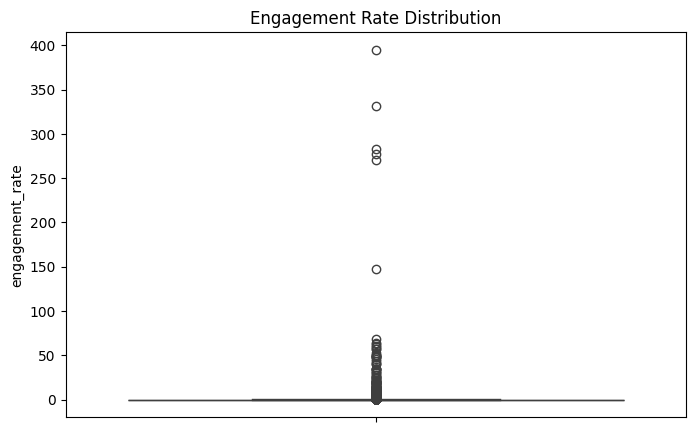

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['engagement_rate']
)

plt.title(
    'Engagement Rate Distribution'
)

plt.show()

### Insight

The boxplot highlights the spread of engagement rates and reveals potential outliers. Extreme values may represent highly successful videos or unusual audience behavior.

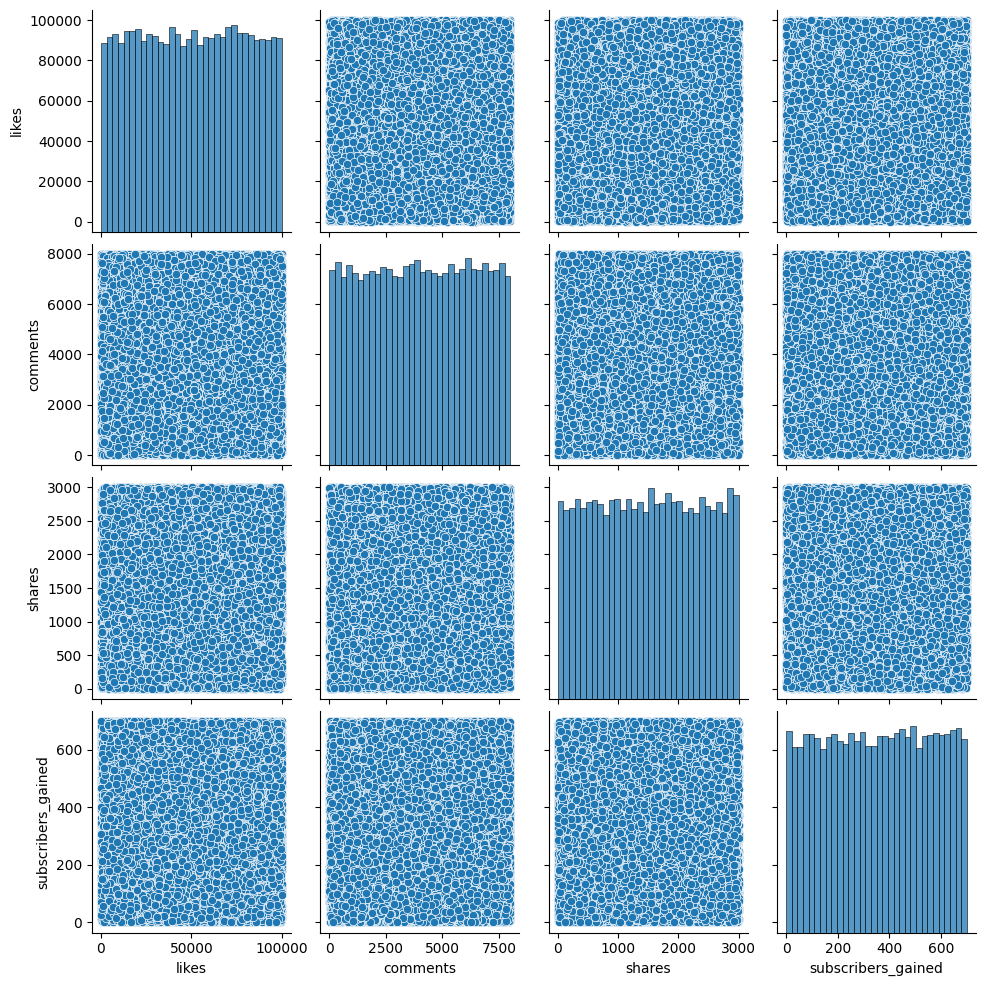

In [24]:
pairplot_cols = [
    'likes',
    'comments',
    'shares',
    'subscribers_gained'
]

sns.pairplot(
    df[pairplot_cols]
)

plt.show()

### Insight

The pairplot provides a broader view of relationships between engagement metrics and subscriber growth, helping identify potential patterns and correlations across multiple variables.

## Sally's Key Findings

This section focuses on advanced engagement analysis. I created new metrics such as engagement rate, subscriber conversion rate, and watch time per impression to better understand how audience interaction connects with video performance.

The analysis compares traffic sources, CTR, impressions, and engagement behavior to identify which factors may contribute to stronger YouTube performance.

In [25]:
# Extract month and day of week

df['month'] = df['upload_date'].dt.month

df['day_of_week'] = df['upload_date'].dt.day_name()

### Insight

The distribution of uploads across weekdays appears relatively balanced, indicating that content is published consistently throughout the week. Understanding these publishing patterns can help identify opportunities to optimize scheduling and audience reach.

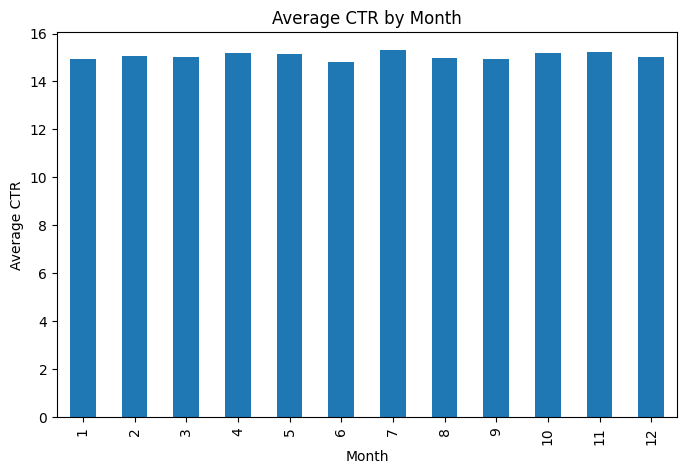

In [26]:
monthly_ctr = df.groupby('month')['ctr_percentage'].mean()

monthly_ctr.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average CTR by Month')
plt.xlabel('Month')
plt.ylabel('Average CTR')

plt.show()

### Insight

The average CTR remains relatively stable across all months, with only minor fluctuations observed throughout the year. This suggests that click-through performance is generally consistent over time and may be influenced more by content quality and audience preferences than by seasonal factors.

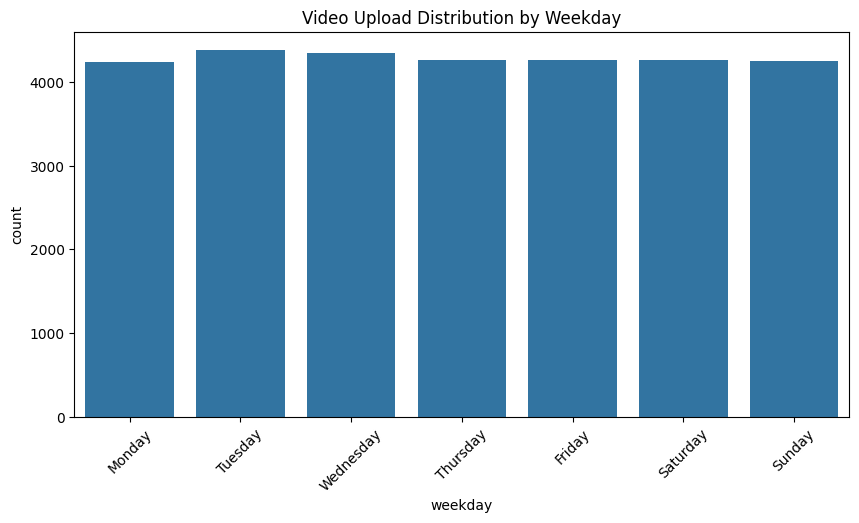

In [27]:
df['weekday'] = df['upload_date'].dt.day_name()

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='weekday',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.xticks(rotation=45)

plt.title('Video Upload Distribution by Weekday')

plt.show()

### Insight

The weekday distribution shows how upload activity is spread throughout the week. Identifying the most common publishing days may help understand content scheduling patterns and audience engagement opportunities.

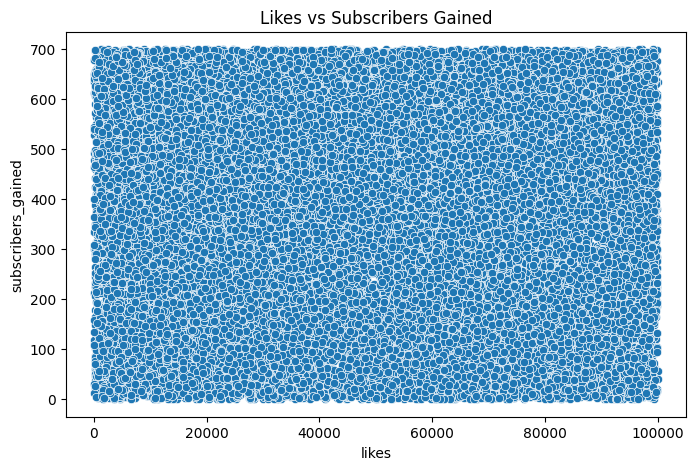

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='likes',
    y='subscribers_gained'
)

plt.title('Likes vs Subscribers Gained')

plt.show()

### Insight

The relationship between likes and subscribers gained appears to be weak to moderate, as subscriber growth is distributed across different levels of likes. While audience interaction may contribute to channel growth, likes alone do not appear to fully explain subscriber acquisition.

Additional factors such as content quality, audience retention, and traffic sources may also influence subscriber growth.

In [29]:
subscriber_corr = df[
    [
        'likes',
        'comments',
        'shares',
        'impressions',
        'ctr_percentage',
        'subscribers_gained'
    ]
].corr()

print(subscriber_corr['subscribers_gained'].sort_values(ascending=False))

subscribers_gained    1.000000
comments              0.009977
impressions           0.001687
ctr_percentage        0.000880
shares               -0.007862
likes                -0.016235
Name: subscribers_gained, dtype: float64


### Insight

The correlation analysis shows that subscriber growth has very weak relationships with the analyzed variables. None of the metrics, including likes, comments, shares, impressions, or CTR, demonstrate a strong linear correlation with subscribers gained.

This suggests that subscriber acquisition may be influenced by additional factors not captured in the dataset, such as content quality, audience retention, viewer preferences, or external promotion.

In [30]:
top_videos = df.sort_values(
    by='subscribers_gained',
    ascending=False
)

top_videos[
    [
        'post_id',
        'subscribers_gained',
        'likes',
        'ctr_percentage'
    ]
].head(10)

,post_id,subscribers_gained,likes,ctr_percentage
3749,YT0003750,700,54746,4.76
2416,YT0002417,700,97219,9.85
21487,YT0021488,700,89431,3.22
9162,YT0009163,700,96688,6.21
9106,YT0009107,700,15657,15.54
9806,YT0009807,700,16435,21.38
12655,YT0012656,700,2544,17.52
2377,YT0002378,700,45755,4.82
21860,YT0021861,700,71393,11.55
22870,YT0022871,700,64615,2.22


### Insight

The top-performing videos all achieved the highest subscriber growth in the dataset. However, these videos show substantial differences in both likes and CTR percentages, suggesting that subscriber acquisition cannot be explained by a single performance metric.

This finding indicates that channel growth is likely influenced by a combination of factors, including audience behavior, content quality, viewer retention, and overall engagement.

In [31]:
Q1 = df['subscribers_gained'].quantile(0.25)
Q3 = df['subscribers_gained'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['subscribers_gained'] < Q1 - 1.5 * IQR) |
    (df['subscribers_gained'] > Q3 + 1.5 * IQR)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


### Insight

The IQR-based outlier detection method did not identify any significant outliers in subscriber growth. This suggests that subscriber acquisition is relatively consistent across the dataset and does not contain extreme observations according to this method.

# Final Conclusion

This project analyzed YouTube performance metrics to better understand audience engagement, CTR, traffic sources, and subscriber growth.

The results indicate that engagement-related metrics such as likes, comments, shares, and watch time are important indicators of overall performance.

Overall, the analysis suggests that subscriber growth is influenced by multiple factors and cannot be fully explained by impressions, likes, comments, shares, or CTR alone.

# Recommendations

- Focus on increasing audience engagement rather than only impressions.
- Optimize traffic sources that generate stronger engagement rates.
- Monitor subscriber conversion metrics alongside CTR.
- Use engagement and watch time metrics when evaluating content success.